In [4]:
install.packages("rjson")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [100]:
library(rjson)
library(parallel)
library(data.table)


Attaching package: ‘data.table’


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second




In [210]:
jsonFileList0 = list.files("/workdir/sh2246/p_phyloGWAS/output/paml_testRun",full.names = T,pattern = '*.RELAX.json')
testRes0 = simplify2array(mclapply(jsonFileList0[1:10],function(x){
    myjson <- fromJSON(file = x,simplify = T)
    if(!length(myjson)==0) return(unlist(myjson$`test results`))
},mc.cores = 20))

In [95]:
jsonFileList = list.files("/workdir/sh2246/p_phyloGWAS/output/RELAXTrees/jsonOutputs",full.names = T)
testRes = simplify2array(mclapply(jsonFileList,function(x){
    myjson <- fromJSON(file = x,simplify = T)
    if(!length(myjson)==0) return(unlist(myjson$`test results`))
},mc.cores = 20))


In [96]:
testRes = t(testRes)
testRes = as.data.frame(testRes)
testRes$logp = -pchisq(testRes$LRT,1,lower.tail = F,log.p = T)/log(10)
testRes$OG = substr(limma::strsplit2(jsonFileList,"/")[,8],1,9)
colnames(testRes)[3] = "k"

In [104]:
fwrite(testRes,"/workdir/sh2246/p_phyloGWAS/output/RELAX_resultTable_annualism.txt",quote = F,sep = "\t")

In [211]:
testRes0 = t(testRes0)
testRes0 = as.data.frame(testRes0)
testRes0$logp = -pchisq(testRes0$LRT,1,lower.tail = F,log.p = T)/log(10)
testRes0$OG = substr(limma::strsplit2(jsonFileList0[1:10],"/")[,7],1,9)
colnames(testRes0)[3] = "k"

In [212]:
subset(testRes,OG%in%testRes0$OG)
testRes0

,LRT,p-value,k,logp,OG
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
OG0000845,0.29720610,0.58563927,0.9763985,0.23236981,OG0000845
OG0000861,0.09557023,0.75721172,1.0287361,0.12078267,OG0000861
OG0000880,2.26802267,0.13206831,1.0738943,0.87920138,OG0000880
OG0000883,-0.01207737,1.00000000,1.0000000,0.00000000,OG0000883
OG0000885,-0.00310024,1.00000000,1.0000000,0.00000000,OG0000885
OG0000887,0.01845468,0.89194144,0.9931801,0.04966366,OG0000887
OG0000905,0.25825662,0.61132042,0.9805640,0.21373110,OG0000905
OG0000908,0.61251979,0.43384064,1.4685978,0.36266977,OG0000908
OG0000923,9.36152257,0.00221588,1.1959861,2.65445377,OG0000923


LRT,p-value,k,logp,OG
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.23988904,0.624286271,0.9508242,0.20461622,OG0000845
0.37667048,0.539390546,1.0294324,0.26809667,OG0000861
0.12364666,0.725112561,1.0156000,0.13959457,OG0000880
0.01579009,0.900002163,1.0060578,0.04575645,OG0000883
0.22450847,0.635625959,1.0159586,0.19679837,OG0000885
0.06134717,0.804379213,0.9933483,0.09453916,OG0000887
0.16582628,0.683848077,0.9810615,0.16504037,OG0000905
0.08116971,0.775718471,1.0897884,0.11029587,OG0000908
9.35836671,0.002219699,1.2027332,2.65370599,OG0000923


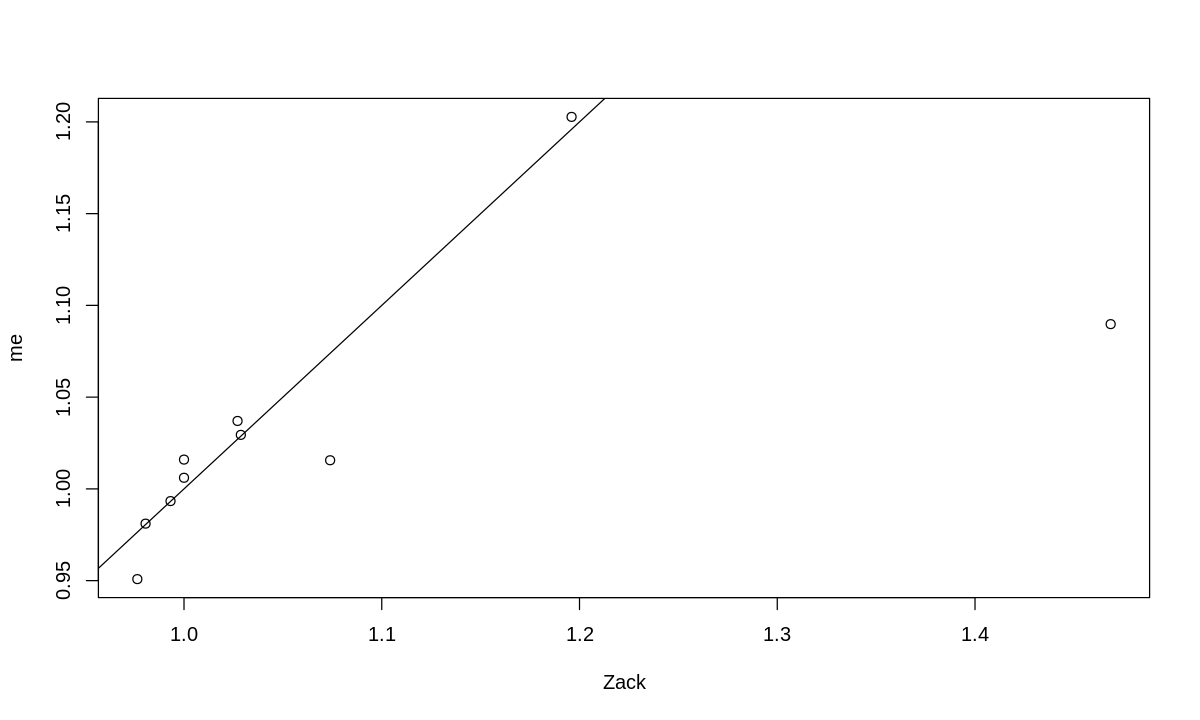

In [213]:
plot(subset(testRes,OG%in%testRes0$OG)[,3],testRes0[,3],xlab = "Zack",ylab = "me")
abline(a=0,b=1)

In [214]:
json1 = fromJSON(file = "/workdir/sh2246/p_phyloGWAS/output/RELAXTrees/jsonOutputs/OG0000883_cleaned.fa.RELAX.json",
                 simplify = T)
json2 = fromJSON(file = "/workdir/sh2246/p_phyloGWAS/output/paml_testRun/OG0000883_cleaned.fa.RELAX.json",
                 simplify = T)

In [215]:
which(unlist(json1$tested)!=unlist(json2$tested))

0.Node1004 0.Node1005 0.Node1008 0.Node1009 0.Node1020 0.Node1021 0.Node1056 
       658        659        660        661        667        668        687 
0.Node1058 0.Node1065 0.Node1068 0.Node1114 0.Node1118  0.Node112 0.Node1122 
       688        690        691        708        711        712        714 
0.Node1183 0.Node1185 0.Node1206 0.Node1210 0.Node1211 0.Node1214 0.Node1266 
       743        744        754        755        756        757        785 
0.Node1270 0.Node1280 0.Node1282 0.Node1290 0.Node1298 0.Node1301 0.Node1305 
       787        793        794        798        801        805        807 
0.Node1336  0.Node134 0.Node1340 0.Node1342 0.Node1369 0.Node1371 0.Node1423 
       823        824        825        826        839        841        867 
0.Node1428 0.Node1439 0.Node1440 0.Node1472 0.Node1477 0.Node1478 0.Node1481 
       869        874        876        885        887        888        890 
0.Node1493 0.Node1498 0.Node1520 0.Node1524 0.Node1534 0.Node1538 0.Node1539 
       899        901        914        916        921        923        924 
0.Node1544 0.Node1549 0.Node1550 0.Node1553 0.Node1555 0.Node1571  0.Node158 
       926        928        929        930        931        938        940 
0.Node1587 0.Node1590  0.Node174   0.Node18  0.Node263   0.Node27  0.Node351 
       943        944        955        960       1000       1004       1047 
  0.Node36  0.Node361   0.Node37  0.Node381  0.Node383  0.Node441  0.Node442 
      1052       1053       1057       1064       1065       1086       1087 
 0.Node443   0.Node45  0.Node471  0.Node474  0.Node477   0.Node48  0.Node493 
      1088       1091       1101       1104       1105       1106       1116 
 0.Node494  0.Node512  0.Node514  0.Node594  0.Node596  0.Node639   0.Node64 
      1117       1127       1128       1167       1168       1191       1192 
 0.Node642  0.Node644  0.Node646   0.Node65  0.Node812   0.Node82  0.Node871 
      1193       1195       1196       1198       1277       1281       1309 
 0.Node872  0.Node911  0.Node915  0.Node918   0.Node92  0.Node961   0.Node97 
      1310       1330       1332       1333       1335       1352       1356

In [167]:
GWASRes = read.table("/workdir/sh2246/p_phyloGWAS/output/fullVsReduced_lifeHistory_241112.txt",header = T)

In [168]:
head(GWASRes)

,OG,BIC_full,BIC_reduced,AIC_full,AIC_reduced,DevianceDifference,p,phyloVAE,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_ESM2,partialP_plantCad,partialP_PMS
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,OG0000185,273.9168,274.5923,240.9091,255.7308,20.82173,0.0001146424,0.9555959,0.50124730,-0.25795737,3.0805411,0.0003456328,0.193699140,0.089386434
2,OG0008909,353.7658,353.5494,320.2905,334.4206,20.13011,0.0001595226,0.9487268,-0.37693750,0.61290994,-0.1392883,0.2049953567,0.010441350,0.941632431
3,OG0025194,352.6668,352.5112,319.4255,333.5162,20.09065,0.0001625553,0.9421754,-0.27760128,0.53376552,-1.2168657,0.6045731857,0.005854871,0.098399892
4,OG0014267,360.0953,359.6868,326.5725,340.5309,19.95846,0.0001731410,0.9449501,0.49998351,-0.32442538,5.0584724,0.8975960922,0.839864423,0.004817207
5,OG0002679,356.5949,355.9939,323.4361,337.0460,19.60990,0.0002044565,0.9422482,-0.02079363,0.86739538,1.3984193,0.9456643614,0.001012136,0.277334337
6,OG0013294,351.0121,350.1306,317.4657,330.9613,19.49556,0.0002159101,0.9466499,0.85708233,-0.02005321,1.3862748,0.3480555978,0.302364353,0.917191880


In [169]:
source("/workdir/sh2246/p_geneModelEvaluation/src/S00_basicFunction.R")

In [204]:
cont_table(GWASRes$OG[rank(GWASRes$partialP_ESM2)<=400],GWASRes$OG,testRes$OG[rank(testRes$p)<=400])
fisher.test(cont_table(GWASRes$OG[rank(GWASRes$partialP_ESM2)<=400],GWASRes$OG,testRes$OG[rank(testRes$p)<=400]))

17,383
262,13613



	Fisher's Exact Test for Count Data

data:  cont_table(GWASRes$OG[rank(GWASRes$partialP_ESM2) <= 400], GWASRes$OG, testRes$OG[rank(testRes$p) <= 400])
p-value = 0.002628
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.309304 3.812857
sample estimates:
odds ratio 
  2.306016 


In [188]:
background = GWASRes$OG

In [184]:
library(ggplot2)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”


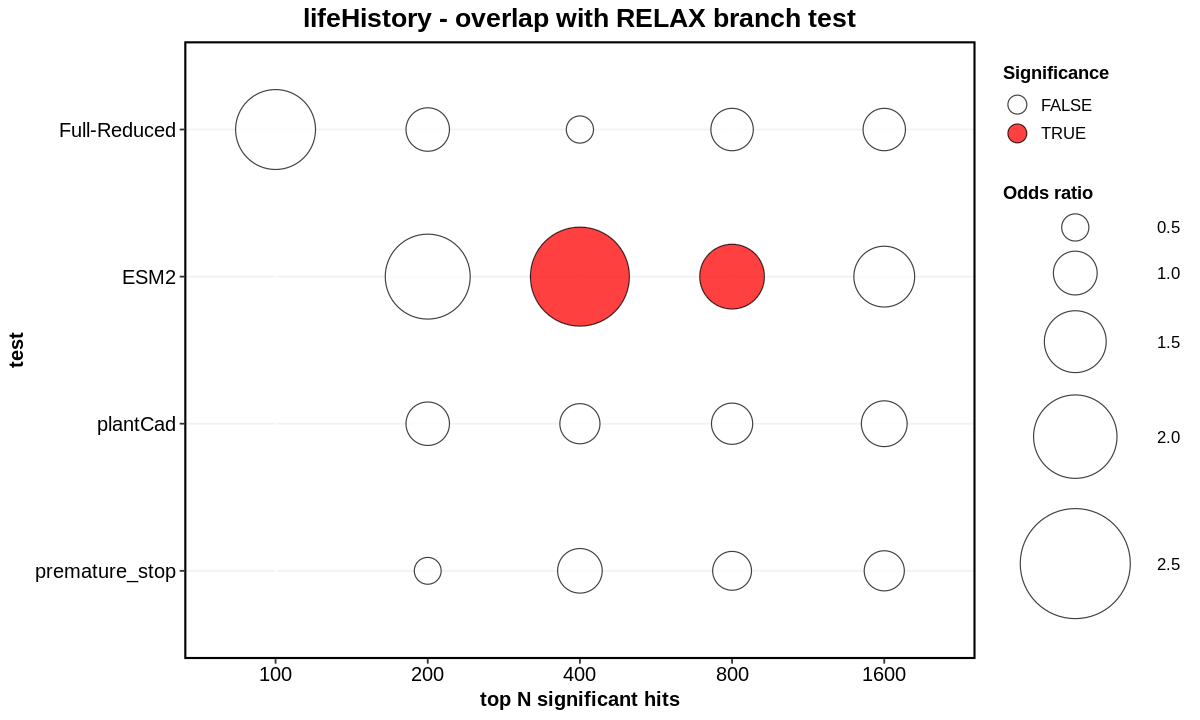

In [206]:
options(repr.plot.width=10, repr.plot.height=6)
# bubble plots
N = c(100,200,400,800,1600)
OR_lifeHistory = c()
p_lifeHistory = c()
for (i in N){
    tmp = GWASRes$OG[rank(GWASRes$p)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,testRes$OG[rank(testRes$p)<=i]),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}
for (i in N){
    tmp = GWASRes$OG[rank(GWASRes$partialP_ESM2)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,testRes$OG[rank(testRes$p)<=i]),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}
for (i in N){
    tmp = GWASRes$OG[rank(GWASRes$partialP_plantCad)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,testRes$OG[rank(testRes$p)<=i]),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}
for (i in N){
    tmp = GWASRes$OG[rank(GWASRes$partialP_PMS)<=i]
    tmpRes = fisher.test(cont_table(tmp,background,testRes$OG[rank(testRes$p)<=i]),alternative = "greater")
    OR_lifeHistory = c(OR_lifeHistory,tmpRes$estimate)
    p_lifeHistory = c(p_lifeHistory,tmpRes$p)
}

enrichmentRes_lifeHistory = data.frame(N = N, OR = OR_lifeHistory,p = p_lifeHistory,
                                       sig = as.character(p_lifeHistory < 0.05 & OR_lifeHistory>1.5),
                                  stress = rep(c("Full-Reduced","ESM2","plantCad","premature_stop"),each = length(N)))
enrichmentRes_lifeHistory$stress = factor(enrichmentRes_lifeHistory$stress,
                                             levels = c("Full-Reduced","ESM2","plantCad","premature_stop"))
ggplot(enrichmentRes_lifeHistory, aes(x = as.factor(N), y = stress),title = "lifeHistory") + 
    geom_point(aes(size = OR, fill = sig), alpha = 0.75, shape = 21) + 
    scale_size_continuous(limits = c(0.01, 3), range = c(.01,40), breaks = c(0.5,1,1.5,2,2.5),transform = 'exp') + 
    labs(title = 'lifeHistory - overlap with RELAX branch test', x= "top N significant hits", y = "test", 
         size = "Odds ratio", fill = "Significance")  + 
    theme(legend.key=element_blank(), 
          plot.title = element_text(colour = "black", size = 16,face = 'bold',hjust = .5),
          axis.title.x = element_text(colour = "black", size = 12,face = 'bold', angle = 0), 
          axis.title.y = element_text(colour = "black", size = 12,face = 'bold'), 
          axis.text.x = element_text(colour = "black", size = 12, angle = 0), 
          axis.text.y = element_text(colour = "black", size = 12), 
          legend.text = element_text(size = 10, colour ="black"), 
          legend.title = element_text(size = 11, face = "bold"), panel.background = element_blank(), 
          panel.border = element_rect(colour = "black", fill = NA, size = 1.2), 
          legend.position = "right", panel.grid.major.y = element_line(colour = "grey95")) +  
    scale_fill_manual(values = c("white","red"), guide = guide_legend(override.aes = list(size=5))) + 
    scale_y_discrete(limits = rev(levels(enrichmentRes_lifeHistory$stress))) 


In [207]:
cont_table(GWASRes$OG[rank(GWASRes$partialP_ESM2)<=400],background,testRes$OG[rank(testRes$p)<=400])
fisher.test(cont_table(GWASRes$OG[rank(GWASRes$partialP_ESM2)<=400],background,testRes$OG[rank(testRes$p)<=400]),
            alternative = "greater")

17,383
262,13613



	Fisher's Exact Test for Count Data

data:  cont_table(GWASRes$OG[rank(GWASRes$partialP_ESM2) <= 400], background, testRes$OG[rank(testRes$p) <= 400])
p-value = 0.002296
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 1.436408      Inf
sample estimates:
odds ratio 
  2.306016 


In [199]:
rownames(testRes) = testRes$OG

[1] 0.01638778

[1] 0.03944899

[1] 0.007563759

[1] 0.01482547

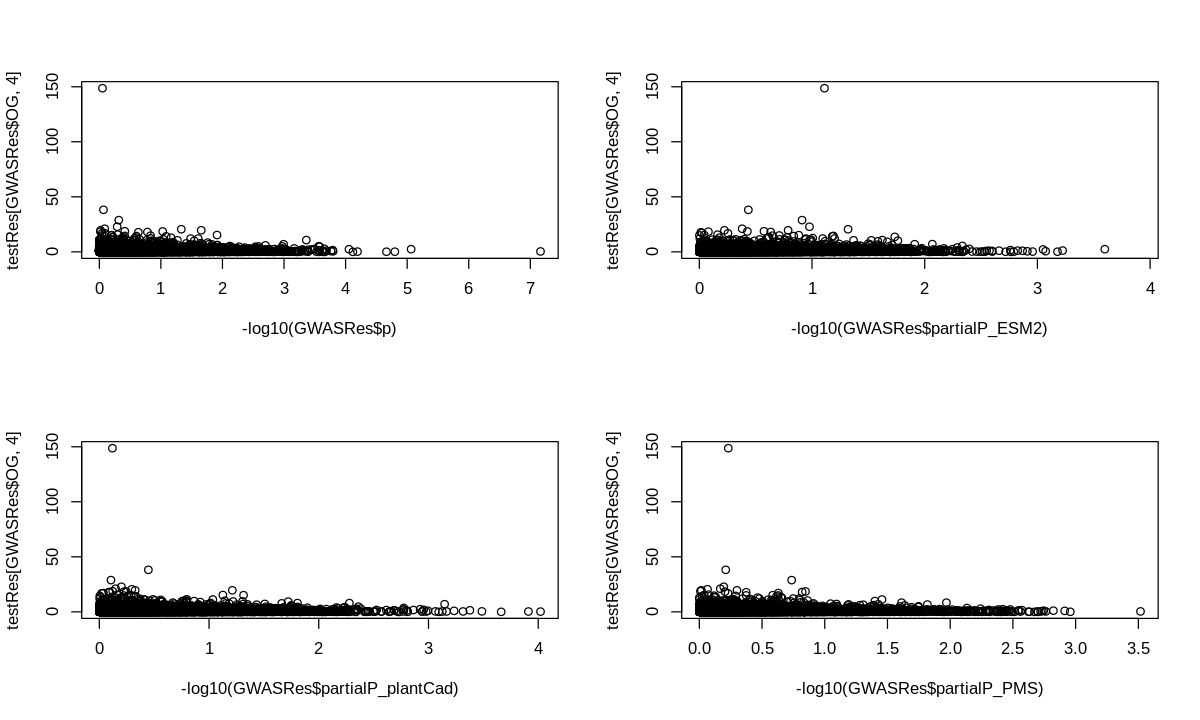

In [203]:
par(mfrow = c(2,2))
plot(-log10(GWASRes$p),testRes[GWASRes$OG,4])
plot(-log10(GWASRes$partialP_ESM2),testRes[GWASRes$OG,4])
plot(-log10(GWASRes$partialP_plantCad),testRes[GWASRes$OG,4])
plot(-log10(GWASRes$partialP_PMS),testRes[GWASRes$OG,4])

cor(-log10(GWASRes$p),testRes[GWASRes$OG,4],use = "complete",method = "spearman")
cor(-log10(GWASRes$partialP_ESM2),testRes[GWASRes$OG,4],use = "complete",method = "spearman")
cor(-log10(GWASRes$partialP_plantCad),testRes[GWASRes$OG,4],use = "complete",method = "spearman")
cor(-log10(GWASRes$partialP_PMS),testRes[GWASRes$OG,4],use = "complete",method = "spearman")

[1] 0.01854138

[1] 0.02005662

[1] -0.008186196

[1] -0.02078945

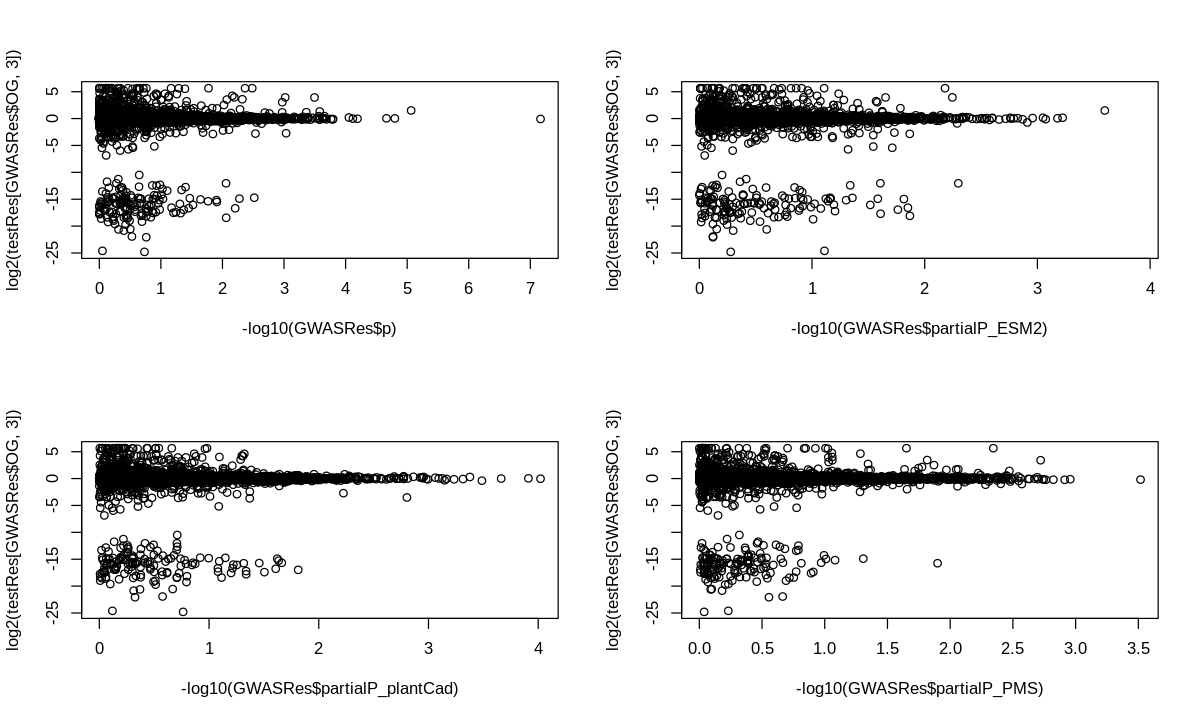

In [209]:
par(mfrow = c(2,2))
plot(-log10(GWASRes$p),log2(testRes[GWASRes$OG,3]))
plot(-log10(GWASRes$partialP_ESM2),log2(testRes[GWASRes$OG,3]))
plot(-log10(GWASRes$partialP_plantCad),log2(testRes[GWASRes$OG,3]))
plot(-log10(GWASRes$partialP_PMS),log2(testRes[GWASRes$OG,3]))

cor(-log10(GWASRes$p),testRes[GWASRes$OG,3],use = "complete",method = "spearman")
cor(-log10(GWASRes$partialP_ESM2),testRes[GWASRes$OG,3],use = "complete",method = "spearman")
cor(-log10(GWASRes$partialP_plantCad),testRes[GWASRes$OG,3],use = "complete",method = "spearman")
cor(-log10(GWASRes$partialP_PMS),testRes[GWASRes$OG,3],use = "complete",method = "spearman")

In [174]:
length(testRes$OG)
length(GWASRes$OG)
length(GWASRes$OG%in%testRes$OG)

[1] 18640

[1] 14275

[1] 14275

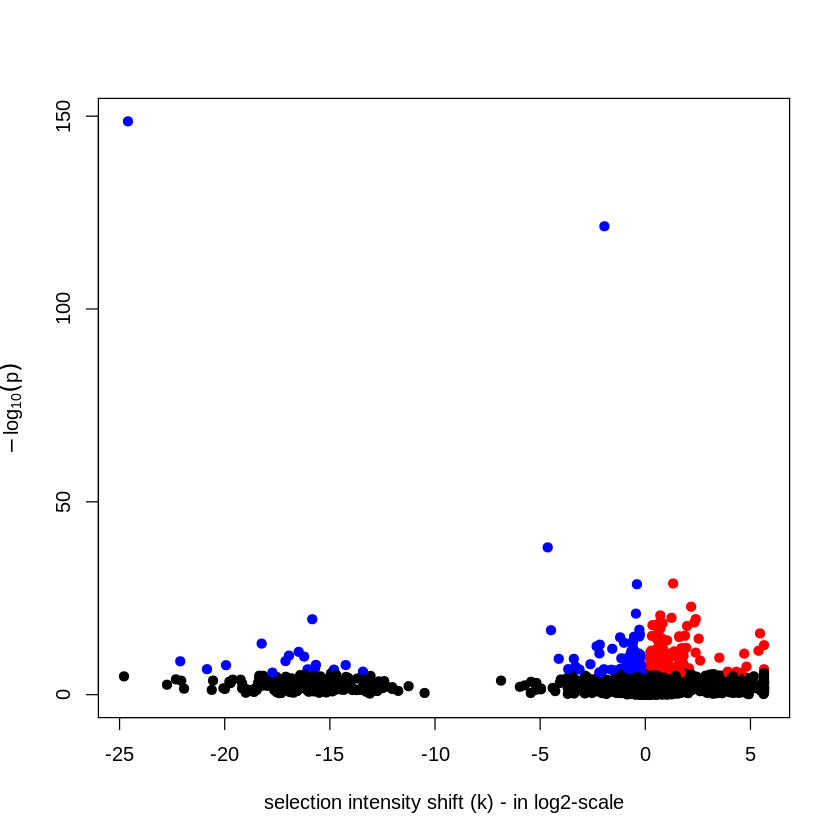

In [105]:
mycol = ifelse(testRes$logp> -log10(0.05/18640),"red","black")
mycol[testRes$logp> -log10(0.05/18640)& testRes[,3]< 1] = "blue"
plot(log2(testRes[,3]),testRes$logp, pch = 19,col = mycol,
     xlab = "selection intensity shift (k) - in log2-scale",ylab = expression(-log[10](p)))

In [79]:
table(mycol)

mycol
black  blue   red 
18319   144   177 

In [107]:
table(testRes[,3]>1)


FALSE  TRUE 
 8807  9833 

In [109]:
fisher.test(matrix(c(144,177,8807-144,9833-177),2,2))


	Fisher's Exact Test for Count Data

data:  matrix(c(144, 177, 8807 - 144, 9833 - 177), 2, 2)
p-value = 0.3981
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.7212209 1.1386374
sample estimates:
odds ratio 
 0.9068385 


In [92]:
library(topGO)
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping_v2.txt")
topHits_Relax = substr(mappingFile[mappingFile[,2]%in%testRes$OG[mycol=="blue"],1],1,15)
topHits_Intensify = substr(mappingFile[mappingFile[,2]%in%testRes$OG[mycol=="red"],1],1,15)
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
background = intersect(names(GODB),substr(mappingFile[,1],1,15))
# background = names(GODB)

tmp=factor(as.integer(background%in%topHits_Relax))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_R=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)

tmp=factor(as.integer(background%in%topHits_Intensify))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table_I=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)



Building most specific GOs .....

	( 3729 GO terms found. )


Build GO DAG topology ..........

	( 5296 GO terms and 11198 relations. )


Annotating nodes ...............

	( 12805 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 1005 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 1005 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 14:	4 nodes to be scored	(0 eliminated genes)


	 Level 13:	11 nodes to be scored	(0 eliminated genes)


	 Level 12:	18 nodes to be scored	(47 eliminated genes)


	 Level 11:	29 nodes to be scored	(226 eliminated genes)


	 Level 10:	74 nodes to be scored	(983 eliminated genes)


	 Level 9:	104 nodes to be scored	(2461 eliminated genes)


	 Level 8:	121 nodes to be scored	(3740 eliminated genes)


	 Level 7:	163 nodes to be scored	(5559 eliminated genes)


	 Level 6:	179 nodes to be scored	(7488 eliminated genes)


	

In [93]:
head(GO_res_table_R,20)
head(GO_res_table_I,20)

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0042335,cuticle development,11,3,0.11,1,0.00014,0.00014
2,GO:0045053,protein retention in Golgi apparatus,6,2,0.06,6,0.00138,0.00138
3,GO:0019740,nitrogen utilization,8,2,0.08,16,0.00255,0.00255
4,GO:0071028,nuclear mRNA surveillance,8,2,0.08,17,0.00255,0.00255
5,GO:0031929,TOR signaling,9,2,0.09,20,0.00325,0.00325
6,GO:0016075,rRNA catabolic process,25,3,0.24,9,0.00179,0.00577
7,GO:0042138,meiotic DNA double-strand break formation,12,2,0.12,30,0.00585,0.00585
8,GO:0010345,suberin biosynthetic process,13,2,0.13,34,0.00687,0.00687
9,GO:0034427,"nuclear-transcribed mRNA catabolic process, exonucleolytic, 3'-5'",13,2,0.13,35,0.00687,0.00687


,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0045935,positive regulation of nucleobase-containing compound metabolic process,422,8,4.65,364,0.09448,0.00035
2,GO:0019985,translesion synthesis,6,2,0.07,7,0.00175,0.00175
3,GO:0106380,purine ribonucleotide salvage,6,2,0.07,8,0.00175,0.00175
4,GO:0010014,meristem initiation,7,2,0.08,10,0.00244,0.00244
5,GO:0006820,anion transport,319,6,3.51,503,0.14043,0.00320
6,GO:0006491,N-glycan processing,8,2,0.09,14,0.00323,0.00323
7,GO:0070413,trehalose metabolism in response to stress,8,2,0.09,15,0.00323,0.00323
8,GO:0010026,trichome differentiation,65,4,0.72,25,0.00567,0.00404
9,GO:0015706,nitrate transmembrane transport,10,2,0.11,24,0.00511,0.00511


In [94]:
head(GO_res_table_R[order(GO_res_table_R$`Rank in Fisher.classic`),],20)
head(GO_res_table_I[order(GO_res_table_I$`Rank in Fisher.classic`),],20)

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,GO:0042335,cuticle development,11,3,0.11,1,0.00014,0.00014
183,GO:0006259,DNA metabolic process,555,15,5.42,2,0.00033,0.27248
92,GO:0015031,protein transport,665,16,6.49,3,0.00074,0.11731
724,GO:0045184,establishment of protein localization,671,16,6.55,4,0.00081,1.00000
886,GO:0071103,DNA conformation change,119,6,1.16,5,0.00108,1.00000
2,GO:0045053,protein retention in Golgi apparatus,6,2,0.06,6,0.00138,0.00138
311,GO:0000291,"nuclear-transcribed mRNA catabolic process, exonucleolytic",23,3,0.22,7,0.00139,1.00000
247,GO:0006886,intracellular protein transport,456,12,4.45,8,0.00166,0.53093
6,GO:0016075,rRNA catabolic process,25,3,0.24,9,0.00179,0.00577


,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
467,GO:0006631,fatty acid metabolic process,194,9,2.14,1,0.00029,1.00000
632,GO:0010629,negative regulation of gene expression,239,10,2.63,2,0.00031,1.00000
122,GO:0009933,meristem structural organization,33,4,0.36,3,0.00045,0.11259
921,GO:0048532,anatomical structure arrangement,36,4,0.40,4,0.00063,1.00000
608,GO:0009987,cellular process,10932,133,120.38,5,0.00069,1.00000
10,GO:0006633,fatty acid biosynthetic process,111,6,1.22,6,0.00141,0.00611
2,GO:0019985,translesion synthesis,6,2,0.07,7,0.00175,0.00175
3,GO:0106380,purine ribonucleotide salvage,6,2,0.07,8,0.00175,0.00175
740,GO:0032261,purine nucleotide salvage,6,2,0.07,9,0.00175,1.00000


In [111]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





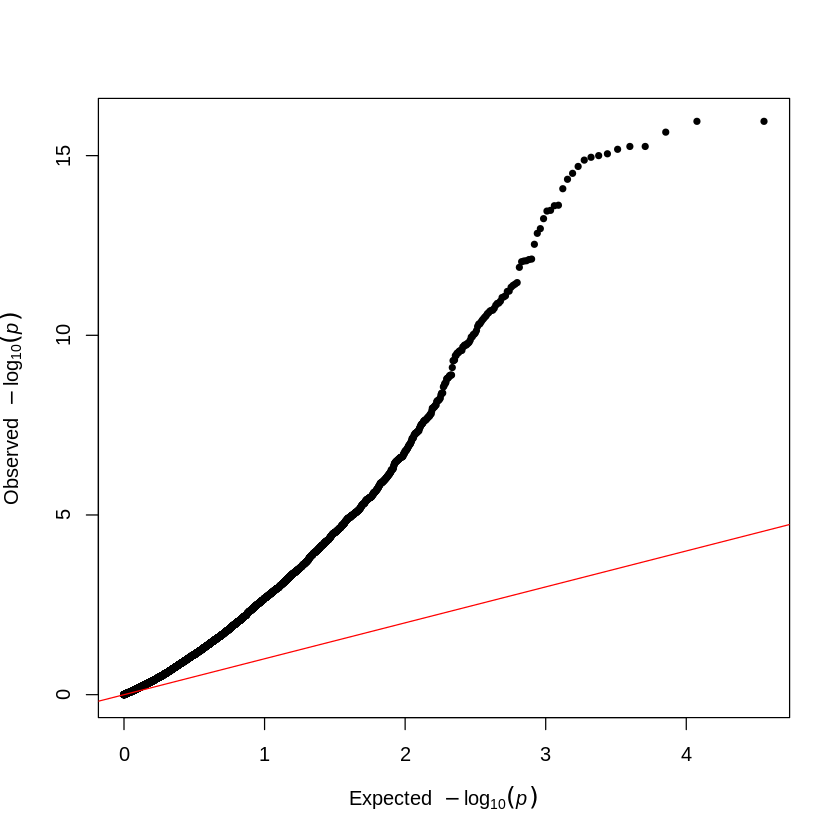

In [112]:
qq(testRes[,2])

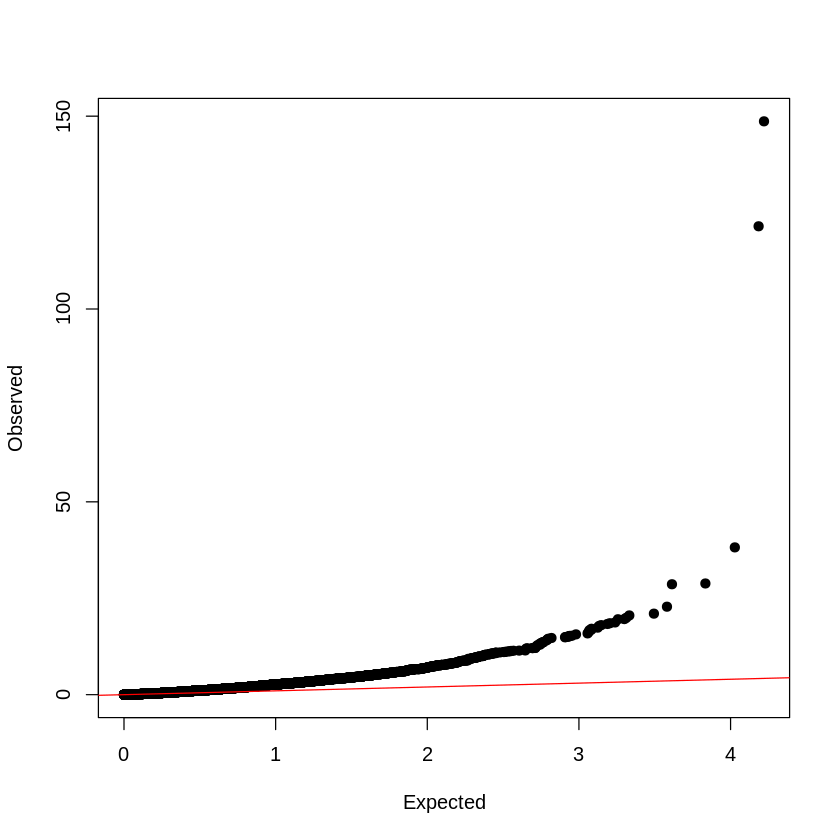

In [118]:
set.seed(123)
plot(sort(-log10(runif(18640,0,1))),sort(testRes[,4]),pch =19, xlab = "Expected",ylab = "Observed")
abline(a=0,b=1,col ="red")

In [114]:
nrow(testRes)

[1] 18640